# **Assignment: Wine Quality Prediction Using ElasticNet Regression**

## **Objective**
The goal of this assignment is to predict the quality of wine based on its physicochemical properties using the **ElasticNet regression algorithm**. You will analyze the dataset, preprocess the data, build the regression model, and evaluate its performance.

### **Dataset Overview**
The Wine Quality dataset contains physicochemical attributes of Portuguese "Vinho Verde" wine samples (both red and white), along with quality ratings. The objective is to model wine quality based on these physicochemical characteristics. The dataset is frequently used in regression and classification tasks in machine learning.ms


#### **Dataset Source**
- [UCI Machine Learning Repository - Wine Quality Dataset](https://archive.ics.uci.edu/ml/datasets/Wine+Quality)
- Citation: "*Modeling wine preferences by data mining from physicochemical properties*," by P. Cortez, A. Cerdeira, Fernando Almeida, Telmo Matos, J. Reis. 2009 Published in Decision Support Systems

### **Columns in the CSV File**
The dataset is presented as a CSV file with the following columns:

| **Column Name**         | **Description**                                                                 |
|--------------------------|---------------------------------------------------------------------------------|
| `fixed acidity`          | Concentration of non-volatile acids (e.g., tartaric acid), expressed in g/dm³. |
| `volatile acidity`       | Concentration of acetic acid, which can affect the taste negatively (g/dm³).   |
| `citric acid`            | Concentration of citric acid, contributing to freshness and taste (g/dm³).     |
| `residual sugar`         | Amount of sugar left after fermentation (g/dm³).                               |
| `chlorides`              | Salt content (g/dm³).                                                          |
| `free sulfur dioxide`    | SO2 in free form; prevents microbial growth and oxidation (mg/dm³).            |
| `total sulfur dioxide`   | Total SO2 content, both free and bound forms (mg/dm³).                         |
| `density`                | Density of the wine; depends on alcohol and sugar (g/cm³).                     |
| `pH`                     | Measure of acidity or basicity of the wine.                                    |
| `sulphates`              | Potassium sulphate level, contributing to flavor (g/dm³).                      |
| `alcohol`                | Alcohol content by volume (%).                                                 |
| `quality`                | Target variable: Quality score of the wine (0 to 10, integer).                 |

---

### **Key Notes**
- **Data Characteristics**: All features are continuous and numeric, except for the `quality` column, which is an ordinal variable.
- **Use Cases**: This dataset is ideal for regression tasks (predicting `quality`) or classification tasks (grouping wine into quality categories).
- **Applications**: It has been used for predictive modeling in wine quality assessment and feature importance analysis.

The dataset provides a real-world scenario for exploring the relationships between physicochemical properties and wine quality.

#### **Number of Attributes**
- **Features (Input Variables)**: 11 continuous numerical attributes
- **Target Variable (Output)**: Wine quality (integer score from 0 to 10)

# **Problem Statement**
You are tasked with developing a predictive model to estimate wine quality scores (target variable) based on a set of physicochemical attributes (input features). Your analysis should include data exploration, preprocessing, modeling, and evaluation steps.

## **Dataset**
   - Use the **Wine Quality Dataset** available from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Wine+Quality).
   - Dataset URL: [Wine CSV](https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv)
   - Hint: `read_csv` has special provisions to read datasets directly from URLs into Pandas DataFrames.
   - Caution: while using `read_csv` with URLs, you need to make sure to specify the separator. So, for example, a valid usage would be
  ```python
    pd.read_csv(url, sep=';')
  ```

In [1]:
import pandas as pd
# URL to the red wine quality CSV
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

# Load the dataset
wine_df = pd.read_csv(url, sep=';')


Print the first 10 rows of your DataFrame.

In [2]:
print(wine_df.head(10))

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   
5            7.4              0.66         0.00             1.8      0.075   
6            7.9              0.60         0.06             1.6      0.069   
7            7.3              0.65         0.00             1.2      0.065   
8            7.8              0.58         0.02             2.0      0.073   
9            7.5              0.50         0.36             6.1      0.071   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


* Display summary statistics and check for missing values.
* What is the mean value of Citric Acid content in the dataset?
* How many missing values are there?
* What is the 3rd quartile of Total Sulfur Dioxide content?
* What is the mean quality of wines in the dataset?
* If `quality=0` describes the worst wine, what is the quality of the best wine in the dataset?

In [7]:
print(wine_df.describe())
print("-------------------------\n")
total_missing = wine_df.isnull().sum().sum()
print(f"Total missing values: {total_missing}")
citric_mean = wine_df['citric acid'].mean()
print(f"Mean citric acid: {citric_mean}")
q3_total_sulfur = wine_df['total sulfur dioxide'].quantile(0.75)
print(f"75th percentile of total sulfur dioxide: {q3_total_sulfur}")
mean_quality = wine_df['quality'].mean()
print(f"Mean wine quality: {mean_quality}")
best_quality = wine_df['quality'].max()
print(f"Best wine quality: {best_quality}")

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

### **Data Visualization**
Visualize the relation between (a) wine quality and total sulfur dioxide, and (b) wine quality and pH as scatterplots. Remember to select the right `hue`.

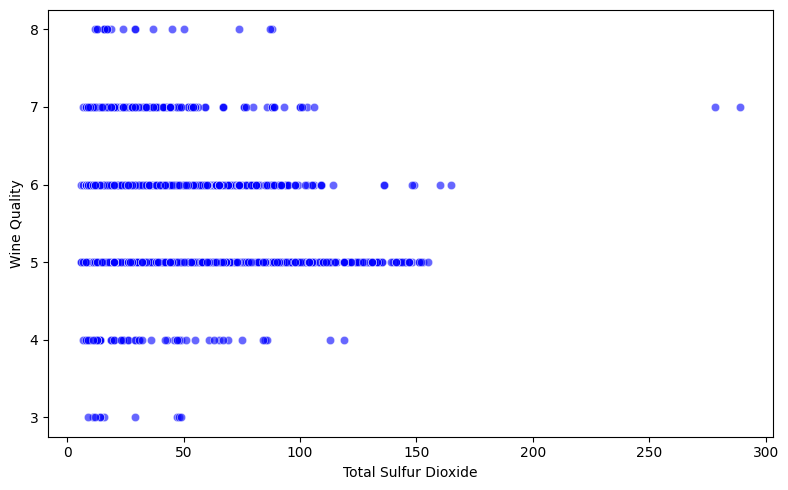

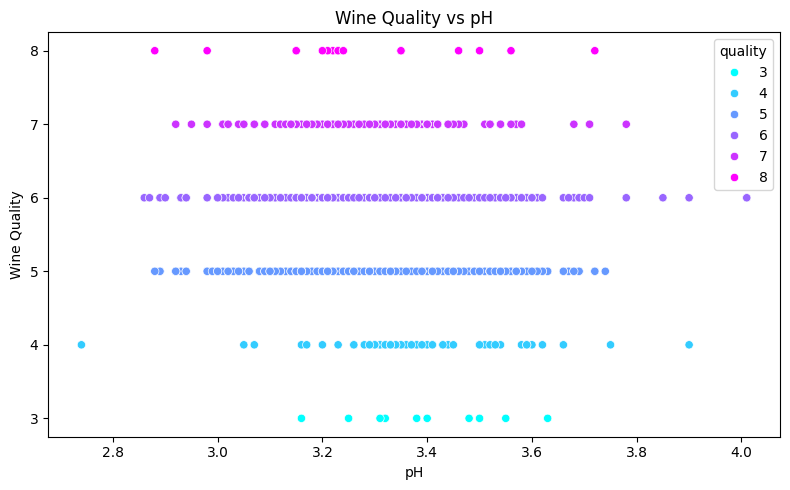

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
sns.scatterplot(data=wine_df, x='total sulfur dioxide', y='quality', color='blue', alpha=0.6)
plt.xlabel('Total Sulfur Dioxide')
plt.ylabel('Wine Quality')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=wine_df, 
    x='pH', 
    y='quality', 
    hue='quality', 
    palette='cool',  
    legend=True  
)
plt.title('Wine Quality vs pH')
plt.xlabel('pH')
plt.ylabel('Wine Quality')
plt.tight_layout()
plt.show()


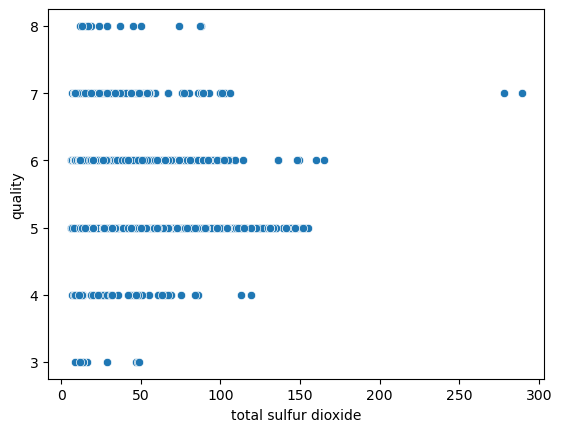

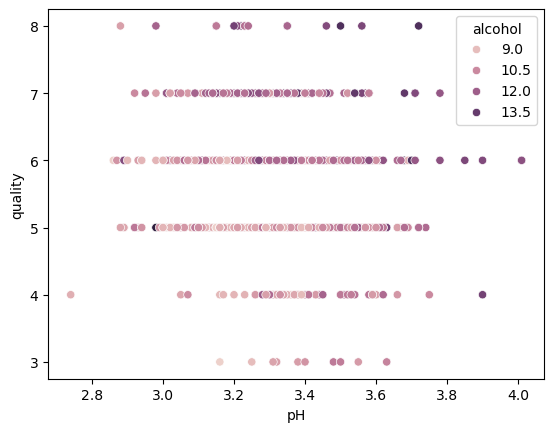

**Data Preprocessing**:
- Scale the features using the `StandardScaler`standardization technique.
- Split the data into training and testing sets (e.g., 80% training, 20% testing).

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = wine_df.drop('quality', axis=1)
y = wine_df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Optional: print shapes to confirm
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1279, 11)
X_test shape: (320, 11)
y_train shape: (1279,)
y_test shape: (320,)


**Model Building**:
- Implement the **ElasticNet regression** algorithm using Scikit-Learn.
- Explain in your own words what the `alpha` and `l1_ratio` parameters do. You will need to carefully examine the Scikit-Learn Documentation for `ElascitNet` to answer this question.
- [Link to](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) ElasticNet documentation.
- Experiment with different values of `alpha` and `l1_ratio` to find the best combination for your model.

* Test your output using the following benchmark parameters: `alpha=1.0`, `l1_ratio=0.5`, `random_state=42`
* Mean Squared Error with the above parameters should be $\approx 0.657$

In [30]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error

# Trying different values for alpha and l1_ratio
alphas = [0.01, 0.05, 0.1, 0.2, 0.5, 0.7, 0.8, 0.9, 1.0]
l1_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

best_mse = float('inf')
best_model = None
best_params = {}

for alpha in alphas:
    for l1_ratio in l1_ratios:
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Calculate RMSE manually
        mse = mean_squared_error(y_test, y_pred)
        
        print(f"Alpha: {alpha}, L1 Ratio: {l1_ratio}, MSE: {mse:.4f}")

        if mse < best_mse:
            best_mse = mse
            best_model = model
            best_params = {'alpha': alpha, 'l1_ratio': l1_ratio}

print("\nBest MSE:", best_mse)
print("Best Params:", best_params)


Alpha: 0.01, L1 Ratio: 0.1, MSE: 0.3906
Alpha: 0.01, L1 Ratio: 0.2, MSE: 0.3911
Alpha: 0.01, L1 Ratio: 0.3, MSE: 0.3916
Alpha: 0.01, L1 Ratio: 0.4, MSE: 0.3919
Alpha: 0.01, L1 Ratio: 0.5, MSE: 0.3922
Alpha: 0.01, L1 Ratio: 0.6, MSE: 0.3924
Alpha: 0.01, L1 Ratio: 0.7, MSE: 0.3925
Alpha: 0.01, L1 Ratio: 0.8, MSE: 0.3926
Alpha: 0.01, L1 Ratio: 0.9, MSE: 0.3928
Alpha: 0.05, L1 Ratio: 0.1, MSE: 0.3936
Alpha: 0.05, L1 Ratio: 0.2, MSE: 0.3949
Alpha: 0.05, L1 Ratio: 0.3, MSE: 0.3963
Alpha: 0.05, L1 Ratio: 0.4, MSE: 0.3981
Alpha: 0.05, L1 Ratio: 0.5, MSE: 0.3999
Alpha: 0.05, L1 Ratio: 0.6, MSE: 0.4020
Alpha: 0.05, L1 Ratio: 0.7, MSE: 0.4043
Alpha: 0.05, L1 Ratio: 0.8, MSE: 0.4068
Alpha: 0.05, L1 Ratio: 0.9, MSE: 0.4091
Alpha: 0.1, L1 Ratio: 0.1, MSE: 0.3975
Alpha: 0.1, L1 Ratio: 0.2, MSE: 0.4012
Alpha: 0.1, L1 Ratio: 0.3, MSE: 0.4052
Alpha: 0.1, L1 Ratio: 0.4, MSE: 0.4100
Alpha: 0.1, L1 Ratio: 0.5, MSE: 0.4145
Alpha: 0.1, L1 Ratio: 0.6, MSE: 0.4197
Alpha: 0.1, L1 Ratio: 0.7, MSE: 0.4241
Alpha: 

## Hyperparameter Tuning

* Instead of `ElasticNet`, we will now use `ELasticNetCV` that also permits Cross Validation.
* Train an `ElasticNetCV` model on this dataset with the following parameters: `alphas=[0.01, 0.1, 1.0, 10.0]`, `l1_ratio=[0.1, 0.25, 0.5, 0.75, 0.9]`, and, as before, `random_state=42`.

In [29]:
from sklearn.linear_model import ElasticNetCV
# Define the grid of alphas and l1_ratios
alphas = [0.01, 0.1, 1.0, 10.0]
l1_ratios = [0.1, 0.25, 0.5, 0.75, 0.9]

# Initialize ElasticNetCV
elastic_cv = ElasticNetCV(alphas=alphas,
                          l1_ratio=l1_ratios,
                          cv=8,              
                          random_state=42)

# Fit model
elastic_cv.fit(X_train, y_train)

# Predict on test set
y_pred = elastic_cv.predict(X_test)

# Calculate RMSE
mse = mean_squared_error(y_test, y_pred)
print(f" MSE: {mse:.4f}")
print(f" Best alpha: {elastic_cv.alpha_}")
print(f" Best l1_ratio: {elastic_cv.l1_ratio_}")

 MSE: 0.3928
 Best alpha: 0.01
 Best l1_ratio: 0.9


* What are the best values of `alpha` and `l1_ratio`?
* Did using cross validation help in any way? Quantify the improvement or lack thereof.

In [ ]:
In the first check we recieved these values:
Best MSE: 0.39062873674773935
Best Params: {'alpha': 0.01, 'l1_ratio': 0.1}
But in the second test we got this:
 MSE: 0.3928
 Best alpha: 0.01
 Best l1_ratio: 0.9
Which differs from the first test completely. We will continue to test the model with both values and see which one is better.
As of now according to the code we have the best value of alpha being 0.01 and l1_ratio being 0.1.

SyntaxError: invalid syntax (3664958376.py, line 1)